# Basic Experiment Notebook
Motor imagery classification on PhysioNet EEG Motor Movement/Imagery Dataset.


## 1. Imports & Config

In [21]:
import os
import numpy as np
import mne
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
import warnings

warnings.filterwarnings('ignore', message='Limited .* annotation.* outside the data range')
mne.set_log_level('WARNING')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ['PYTHONHASHSEED'] = str(SEED)

# ── Paths & dataset constants ────────────────────────────────────────────────
DATA_DIR = os.path.join(os.getcwd(), '../files')

# Runs with left/right hand motor imagery (Task 1: close left or right fist)
RUNS = ['R03', 'R04', 'R07', 'R08', 'R11', 'R12']

# Number of subjects to use (1–109); set to None to use all
N_SUBJECTS = 109

SFREQ     = 160    # Hz — native sample rate
TMIN      = 0.0   # epoch start (s) relative to event onset
TMAX      = 2.0   # epoch end   (s)
N_SAMPLES = int(SFREQ * (TMAX - TMIN))  # 320 samples per epoch
N_CHANNELS = 64

# ── Filtering ────────────────────────────────────────────────────────────────
NOTCH_FREQ  = 60.0 
BP_LOW      = 4.0         # bandpass lower edge  (Hz)
BP_HIGH     = 40.0        # bandpass upper edge  (Hz)

# ── Train / val / test split fractions ──────────────────────────────────────
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15
# TEST_FRAC  = 1 - TRAIN_FRAC - VAL_FRAC  (implicit)

BATCH_SIZE = 64
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cpu


## 2. Data Loading & Preprocessing

In [22]:
def load_subject(subject_id):
    """Load all runs for one subject, apply notch + bandpass, return (X, y).

    Returns
    -------
    X : ndarray, shape (n_epochs, n_channels, n_samples)
    y : ndarray, shape (n_epochs,)  — 0=left hand, 1=right hand
    """
    subject = f'S{subject_id:03d}'
    raws = []

    for run in RUNS:
        path = os.path.join(DATA_DIR, subject, f'{subject}{run}.edf')
        if not os.path.exists(path):
            continue
        raw = mne.io.read_raw_edf(path, preload=True, verbose=False)

        # Notch filter — remove power-line artifact
        # raw.notch_filter(NOTCH_FREQ, verbose=False)

        # Bandpass filter — keep motor-imagery relevant frequencies
        # raw.filter(BP_LOW, BP_HIGH, verbose=False)

        raws.append(raw)

    if not raws:
        return np.empty((0, N_CHANNELS, 0)), np.empty((0,), dtype=int)

    raw = mne.concatenate_raws(raws)
    events, event_id = mne.events_from_annotations(raw)

    # Some files only have T0 (rest); skip if T1/T2 not present
    if 'T1' not in event_id or 'T2' not in event_id:
        return np.empty((0, N_CHANNELS, 0)), np.empty((0,), dtype=int)

    epochs = mne.Epochs(
        raw,
        events,
        event_id={'T1': event_id['T1'], 'T2': event_id['T2']},
        tmin=TMIN, tmax=TMAX,
        baseline=None,
        preload=True,
        verbose=False,
    )

    X = epochs.get_data()  # (n_epochs, 64, n_times)
    y = epochs.events[:, -1]
    y = (y == event_id['T2']).astype(int)  # T1=left=0, T2=right=1

    # Trim / pad to exactly N_SAMPLES
    X_fixed = []
    for x in X:
        if x.shape[1] >= N_SAMPLES:
            x = x[:, :N_SAMPLES]
        else:
            x = np.pad(x, ((0, 0), (0, N_SAMPLES - x.shape[1])))
        X_fixed.append(x)

    return np.stack(X_fixed), y


def load_all_subjects(n_subjects=N_SUBJECTS):
    """Load epochs from all subjects and pool them into one array."""
    X_all, y_all = [], []
    for sid in range(1, n_subjects + 1):
        X, y = load_subject(sid)
        if len(X) == 0:
            continue
        X_all.append(X)
        y_all.append(y)
    return np.concatenate(X_all), np.concatenate(y_all)

In [23]:
print('Loading all subjects...')
X_all, y_all = load_all_subjects()
print(f'Total epochs: {len(X_all)} | Shape: {X_all.shape}')
print(f'Class balance — left: {(y_all==0).sum()} | right: {(y_all==1).sum()}')

Loading all subjects...
Total epochs: 9845 | Shape: (9845, 64, 320)
Class balance — left: 4951 | right: 4894


## 3. Normalisation & Random Train / Val / Test Split

In [24]:
def normalize(X):
    """Per-epoch, per-channel z-score normalisation + add channel dim for Conv2d."""
    mu  = X.mean(axis=2, keepdims=True)   # (N, C, 1)
    std = X.std(axis=2,  keepdims=True) + 1e-6
    X   = (X - mu) / std
    return X[:, np.newaxis, :, :]         # (N, 1, C, T)


class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [25]:
# Normalise all data first, then split
X_norm = normalize(X_all)

n_total = len(X_norm)
idx = np.random.permutation(n_total)

n_train = int(n_total * TRAIN_FRAC)
n_val   = int(n_total * VAL_FRAC)

train_idx = idx[:n_train]
val_idx   = idx[n_train : n_train + n_val]
test_idx  = idx[n_train + n_val :]

full_dataset = EEGDataset(X_norm, y_all)

train_loader = DataLoader(Subset(full_dataset, train_idx), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(Subset(full_dataset, val_idx),   batch_size=BATCH_SIZE)
test_loader  = DataLoader(Subset(full_dataset, test_idx),  batch_size=BATCH_SIZE)

print(f'Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}')

Train: 6891 | Val: 1476 | Test: 1478


## 4. EEGNet with Inception Model

In [26]:
class EEGNetInception(nn.Module):
    """EEGNet backbone with an EEG-ITNet-style inception front end.

    Input: (B, 1, n_channels, n_samples)
    """
    def __init__(self, n_channels=64, n_samples=320, n_classes=2,
                 inception_filters=(2, 4, 8), kernel_sizes=(16, 32, 64),
                 D=2, F2=16, dropout=0.25):
        super().__init__()

        if len(inception_filters) != len(kernel_sizes):
            raise ValueError('inception_filters and kernel_sizes must have the same length')

        self.temporal_branches = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(1, out_channels, (1, kernel_size), padding='same', bias=False),
                nn.BatchNorm2d(out_channels),
            )
            for out_channels, kernel_size in zip(inception_filters, kernel_sizes)
        ])

        temporal_channels = sum(inception_filters)

        # EEGNet-style depthwise spatial filtering after inception fusion.
        self.block1 = nn.Sequential(
            nn.Conv2d(
                temporal_channels,
                temporal_channels * D,
                (n_channels, 1),
                groups=temporal_channels,
                bias=False,
            ),
            nn.BatchNorm2d(temporal_channels * D),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(dropout),
        )

        # EEGNet-style separable temporal refinement.
        self.block2 = nn.Sequential(
            nn.Conv2d(
                temporal_channels * D,
                temporal_channels * D,
                (1, 16),
                padding='same',
                groups=temporal_channels * D,
                bias=False,
            ),
            nn.Conv2d(temporal_channels * D, F2, (1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d((1, 8)),
            nn.Dropout(dropout),
        )

        flatten_dim = self._infer_flatten_dim(n_channels, n_samples)
        self.classifier = nn.Linear(flatten_dim, n_classes)

    def _infer_flatten_dim(self, n_channels, n_samples):
        with torch.no_grad():
            x = torch.zeros(1, 1, n_channels, n_samples)
            x = torch.cat([branch(x) for branch in self.temporal_branches], dim=1)
            x = self.block1(x)
            x = self.block2(x)
        return x.flatten(start_dim=1).shape[1]

    def forward(self, x):
        x = torch.cat([branch(x) for branch in self.temporal_branches], dim=1)
        x = self.block1(x)
        x = self.block2(x)
        x = x.flatten(start_dim=1)
        return self.classifier(x)


model = EEGNetInception(n_channels=N_CHANNELS, n_samples=N_SAMPLES)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'EEGNetInception params: {n_params:,}')

EEGNetInception params: 3,798


## 5. Training

In [27]:
def train(model, train_loader, val_loader, epochs=50, lr=1e-3):
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(1, epochs + 1):
        # ── Train ────────────────────────────────────────────────────────────
        model.train()
        total_loss = 0.0
        for X, y in train_loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(X), y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # ── Validate ─────────────────────────────────────────────────────────
        model.eval()
        correct = total = 0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(DEVICE), y.to(DEVICE)
                correct += (model(X).argmax(1) == y).sum().item()
                total   += len(y)

        print(f'Epoch {epoch:3d} | Loss: {total_loss:.2f} | Val Acc: {correct/total:.4f}')

In [28]:
train(model, train_loader, val_loader, epochs=50)

Epoch   1 | Loss: 55.44 | Val Acc: 0.8198
Epoch   2 | Loss: 45.61 | Val Acc: 0.8232
Epoch   3 | Loss: 43.69 | Val Acc: 0.8306
Epoch   4 | Loss: 42.14 | Val Acc: 0.8455
Epoch   5 | Loss: 41.45 | Val Acc: 0.8340
Epoch   6 | Loss: 40.68 | Val Acc: 0.8347
Epoch   7 | Loss: 40.29 | Val Acc: 0.8381
Epoch   8 | Loss: 39.53 | Val Acc: 0.8360
Epoch   9 | Loss: 39.49 | Val Acc: 0.8408
Epoch  10 | Loss: 39.01 | Val Acc: 0.8367
Epoch  11 | Loss: 39.12 | Val Acc: 0.8245
Epoch  12 | Loss: 38.24 | Val Acc: 0.8388
Epoch  13 | Loss: 38.19 | Val Acc: 0.8313
Epoch  14 | Loss: 37.84 | Val Acc: 0.8340
Epoch  15 | Loss: 38.01 | Val Acc: 0.8449
Epoch  16 | Loss: 37.65 | Val Acc: 0.8347
Epoch  17 | Loss: 36.96 | Val Acc: 0.8327
Epoch  18 | Loss: 36.23 | Val Acc: 0.8374
Epoch  19 | Loss: 36.37 | Val Acc: 0.8455
Epoch  20 | Loss: 35.95 | Val Acc: 0.8421
Epoch  21 | Loss: 35.47 | Val Acc: 0.8421
Epoch  22 | Loss: 35.34 | Val Acc: 0.8320
Epoch  23 | Loss: 35.76 | Val Acc: 0.8435
Epoch  24 | Loss: 34.93 | Val Acc:

## 6. Test Evaluation

In [29]:
def evaluate(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            correct += (model(X).argmax(1) == y).sum().item()
            total   += len(y)
    return correct / total

test_acc = evaluate(model, test_loader)
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.8396


## 7. Performance Diagnostics

Performance summary for EEGNetInception
Train      Accuracy: 0.8964
Validation Accuracy: 0.8449
Test       Accuracy: 0.8396

Test Classification Report
              precision    recall  f1-score   support

   Left hand       0.86      0.82      0.84       754
  Right hand       0.82      0.85      0.84       724

    accuracy                           0.84      1478
   macro avg       0.84      0.84      0.84      1478
weighted avg       0.84      0.84      0.84      1478

Test ROC AUC: 0.9265


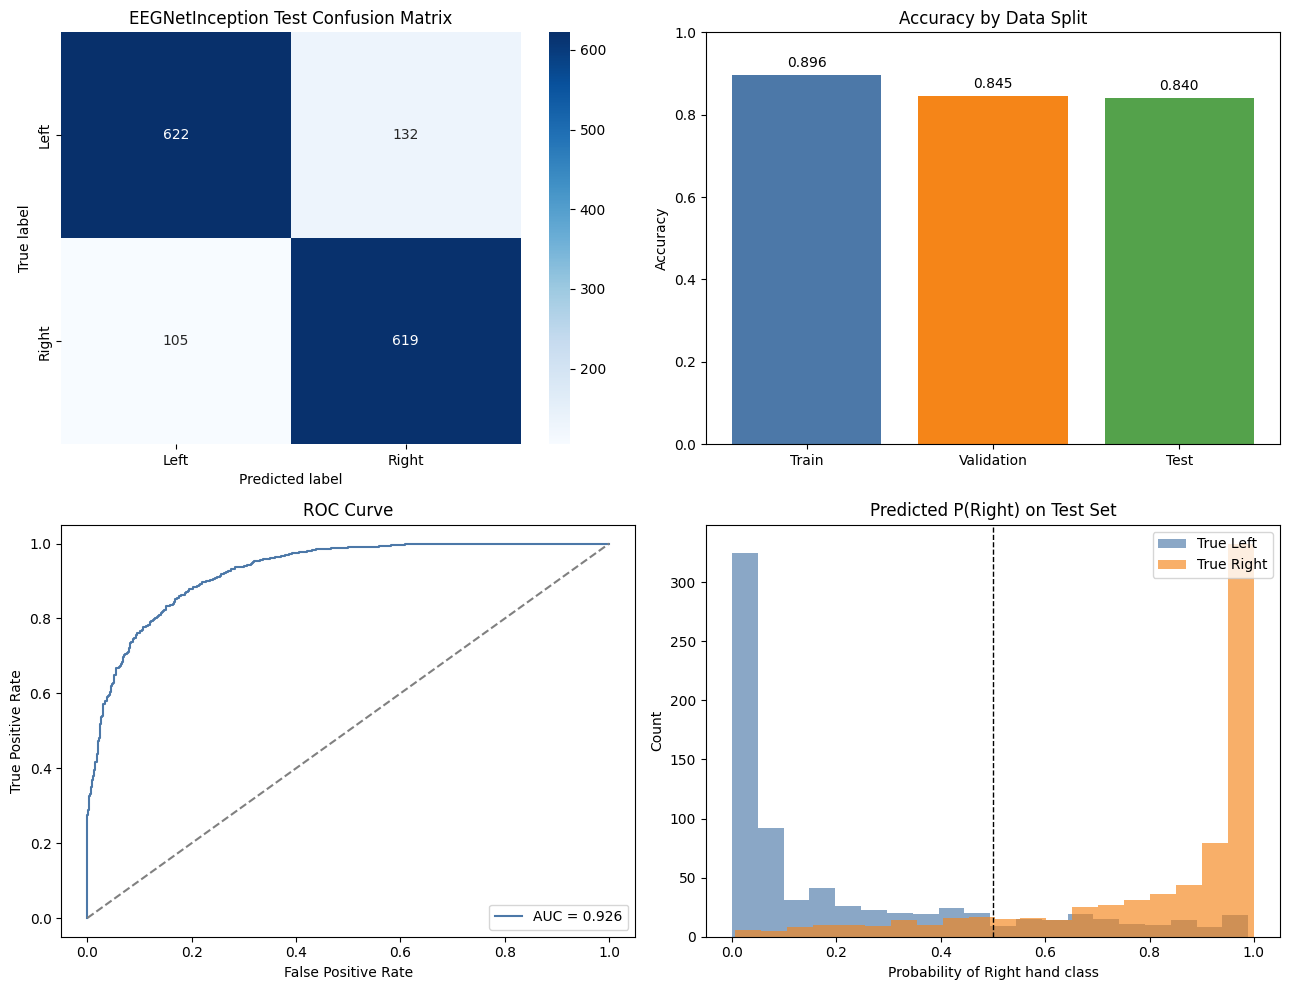

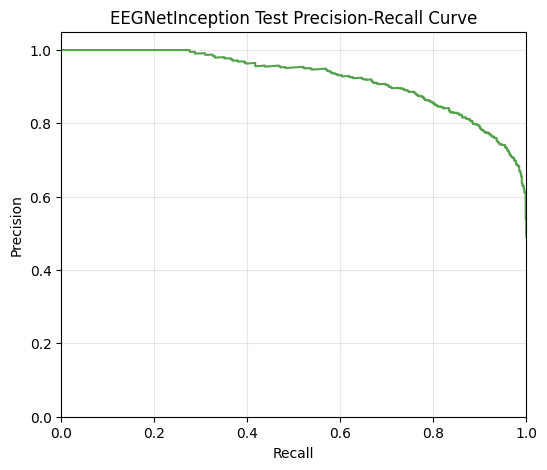

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

def collect_predictions(model, loader):
    model.eval()
    all_probs, all_preds, all_targets = [], [], []
    with torch.no_grad():
        for X, y in loader:
            X = X.to(DEVICE)
            logits = model(X)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds = probs.argmax(axis=1)
            all_probs.append(probs)
            all_preds.append(preds)
            all_targets.append(y.numpy())
    return (
        np.concatenate(all_targets),
        np.concatenate(all_preds),
        np.concatenate(all_probs),
    )

split_results = {}
for split_name, loader in [('Train', train_loader), ('Validation', val_loader), ('Test', test_loader)]:
    y_true, y_pred, y_prob = collect_predictions(model, loader)
    split_results[split_name] = {'y_true': y_true, 'y_pred': y_pred, 'y_prob': y_prob}

model_name = type(model).__name__
print(f'Performance summary for {model_name}')
for split_name, result in split_results.items():
    acc = accuracy_score(result['y_true'], result['y_pred'])
    print(f'{split_name:10s} Accuracy: {acc:.4f}')

y_true = split_results['Test']['y_true']
y_pred = split_results['Test']['y_pred']
y_prob = split_results['Test']['y_prob'][:, 1]

print('\nTest Classification Report')
print(classification_report(y_true, y_pred, target_names=['Left hand', 'Right hand']))
print(f'Test ROC AUC: {roc_auc_score(y_true, y_prob):.4f}')

cm = confusion_matrix(y_true, y_pred)
fpr, tpr, _ = roc_curve(y_true, y_prob)
precision, recall, _ = precision_recall_curve(y_true, y_prob)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Left', 'Right'],
    yticklabels=['Left', 'Right'],
    ax=axes[0, 0],
)
axes[0, 0].set_title(f'{model_name} Test Confusion Matrix')
axes[0, 0].set_xlabel('Predicted label')
axes[0, 0].set_ylabel('True label')

split_names = list(split_results.keys())
split_accs = [accuracy_score(split_results[name]['y_true'], split_results[name]['y_pred']) for name in split_names]
axes[0, 1].bar(split_names, split_accs, color=['#4c78a8', '#f58518', '#54a24b'])
axes[0, 1].set_ylim(0.0, 1.0)
axes[0, 1].set_title('Accuracy by Data Split')
axes[0, 1].set_ylabel('Accuracy')
for idx, acc in enumerate(split_accs):
    axes[0, 1].text(idx, acc + 0.02, f'{acc:.3f}', ha='center')

axes[1, 0].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_true, y_prob):.3f}', color='#4c78a8')
axes[1, 0].plot([0, 1], [0, 1], '--', color='gray')
axes[1, 0].set_title('ROC Curve')
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].legend(loc='lower right')

axes[1, 1].hist(y_prob[y_true == 0], bins=20, alpha=0.65, label='True Left', color='#4c78a8')
axes[1, 1].hist(y_prob[y_true == 1], bins=20, alpha=0.65, label='True Right', color='#f58518')
axes[1, 1].axvline(0.5, linestyle='--', color='black', linewidth=1)
axes[1, 1].set_title('Predicted P(Right) on Test Set')
axes[1, 1].set_xlabel('Probability of Right hand class')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='#54a24b')
plt.title(f'{model_name} Test Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim(0.0, 1.05)
plt.xlim(0.0, 1.0)
plt.grid(alpha=0.3)
plt.show()
